# Stage 1: Dataset Exploration and Preprocessing

This notebook covers the initial stage of the machine learning pipeline, including dataset loading, exploration, visualization, and preprocessing.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load and Explore the Dataset

In [4]:
# Define dataset path
dataset_path = Path('food_subset')

# Get all class directories
classes = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

print("Number of classes:", len(classes))
print("Classes:", classes)

# Load dataset information
data_info = {}
for class_name in classes:
    class_path = dataset_path / class_name
    images = sorted(list(class_path.glob('*.jpg')))
    data_info[class_name] = len(images)

print("Dataset Overview")
print("Number of images per class:")
for class_name, count in data_info.items():
    print(class_name + ":", count)

total_images = sum(data_info.values())
print()
print("Total number of images:", total_images)
print("Average images per class:", round(total_images / len(classes), 2))

Number of classes: 10
Classes: ['chocolate_cake', 'donuts', 'falafel', 'french_fries', 'hamburger', 'ice_cream', 'pizza', 'spaghetti_bolognese', 'steak', 'waffles']
Dataset Overview
Number of images per class:
chocolate_cake: 400
donuts: 400
falafel: 400
french_fries: 400
hamburger: 400
ice_cream: 400
pizza: 400
spaghetti_bolognese: 400
steak: 400
waffles: 400

Total number of images: 4000
Average images per class: 400.0


## 2. Display Sample Images

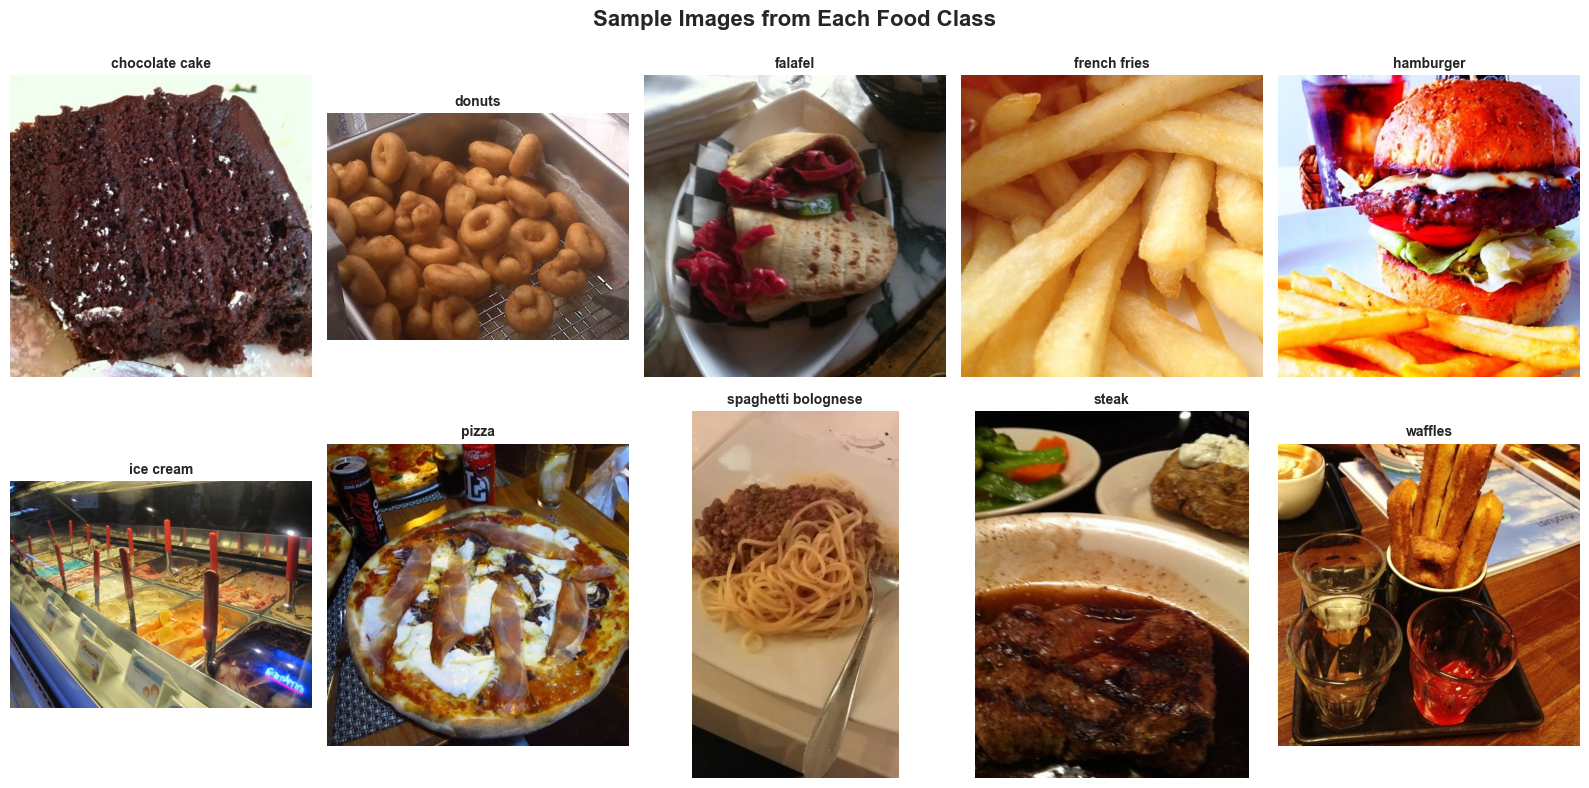

In [6]:
# Display sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle('Sample Images from Each Food Class', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, class_name in enumerate(classes):
    class_path = dataset_path / class_name
    images = sorted(list(class_path.glob('*.jpg')))
    if images:
        # Load first image from the class
        img = Image.open(images[107])
        axes[idx].imshow(img)
        axes[idx].set_title(class_name.replace('_', ' '), fontsize=10, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3. Analyze Class Distribution

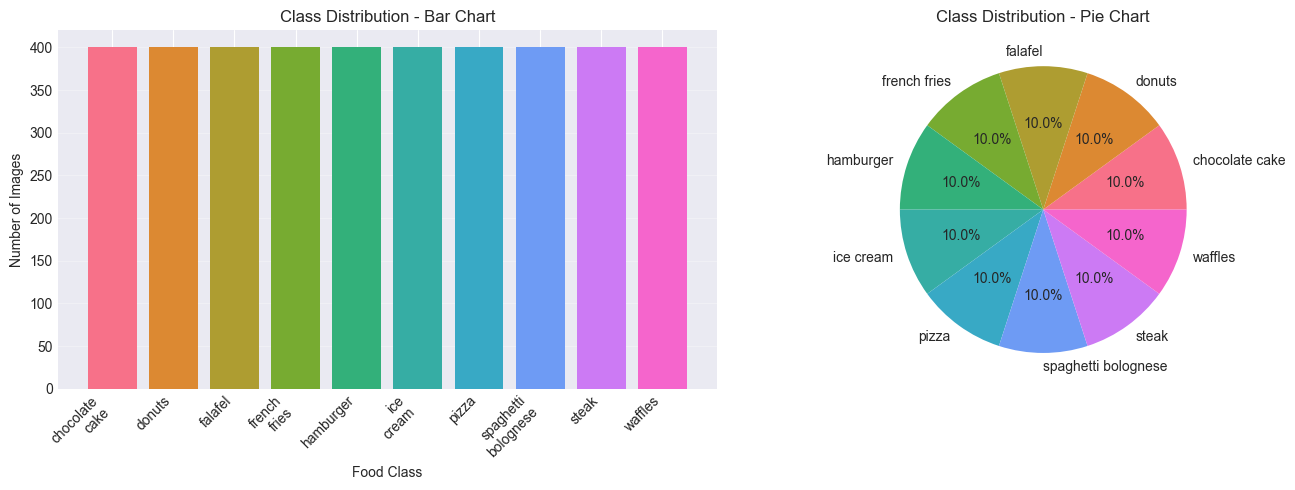

Class distribution stats
min: 400
max: 400
mean: 400.0
std: 0.0
max/min ratio: 1.0


In [7]:
# Create visualizations for class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_names = list(data_info.keys())
class_counts = list(data_info.values())

axes[0].bar(range(len(class_names)), class_counts, color=sns.color_palette("husl", len(class_names)))
axes[0].set_xlabel('Food Class')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Class Distribution - Bar Chart')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_xticklabels([name.replace('_', '\n') for name in class_names], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_counts, labels=[name.replace('_', ' ') for name in class_names], autopct='%1.1f%%',
            colors=sns.color_palette("husl", len(class_names)))
axes[1].set_title('Class Distribution - Pie Chart')

plt.tight_layout()
plt.show()

# Simple class balance stats
counts = np.array(class_counts)
print('Class distribution stats')
print('min:', counts.min())
print('max:', counts.max())
print('mean:', round(counts.mean(), 2))
print('std:', round(counts.std(), 2))
print('max/min ratio:', round(counts.max() / counts.min(), 2))

## 4. Load and Resize Images

In [8]:
# Define target image size for resizing
TARGET_SIZE = 128  # Smaller size for faster and more stable training

# Function to load and resize images
def load_and_resize_images(dataset_path, classes, target_size=224):
    # Load all images from the dataset and resize them to target size.
    # Returns: images (array), labels (array), class_names (list)
    images = []
    labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_path = dataset_path / class_name
        image_files = sorted(list(class_path.glob('*.jpg')))
        
        for img_path in image_files:
            try:
                # Load image
                img = Image.open(img_path).convert('RGB')
                # Resize image
                img_resized = img.resize((target_size, target_size), Image.LANCZOS)
                # Convert to numpy array
                img_array = np.array(img_resized)
                
                images.append(img_array)
                labels.append(class_idx)
            except Exception as e:
                print('Error processing', img_path, ':', e)
                continue
        
        class_loaded_count = np.sum(np.array(labels) == class_idx)
        print('Loaded', class_loaded_count, 'images for class', class_name)
    
    return np.array(images), np.array(labels), classes

# Load and resize images
X, y, class_names = load_and_resize_images(dataset_path, classes, TARGET_SIZE)


print("\nDataset Loaded and Resized")

print('Dataset shape:', X.shape)
print('Labels shape:', y.shape)
print('Image dimensions:', str(TARGET_SIZE) + 'x' + str(TARGET_SIZE) + 'x3 (RGB)')
print('Unique classes:', np.unique(y))

Loaded 400 images for class chocolate_cake
Loaded 400 images for class donuts
Loaded 400 images for class falafel
Loaded 400 images for class french_fries
Loaded 400 images for class hamburger
Loaded 400 images for class ice_cream
Loaded 400 images for class pizza
Loaded 400 images for class spaghetti_bolognese
Loaded 400 images for class steak
Loaded 400 images for class waffles

Dataset Loaded and Resized
Dataset shape: (4000, 128, 128, 3)
Labels shape: (4000,)
Image dimensions: 128x128x3 (RGB)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


## 5. Normalize Pixel Values

Original pixel value statistics:
  Min value: 0
  Max value: 255
  Mean value: 112.57
  Std deviation: 73.06

Normalized pixel value statistics (0-1 range):
  Min value: 0.0
  Max value: 1.0
  Mean value: 0.4414
  Std deviation: 0.2865


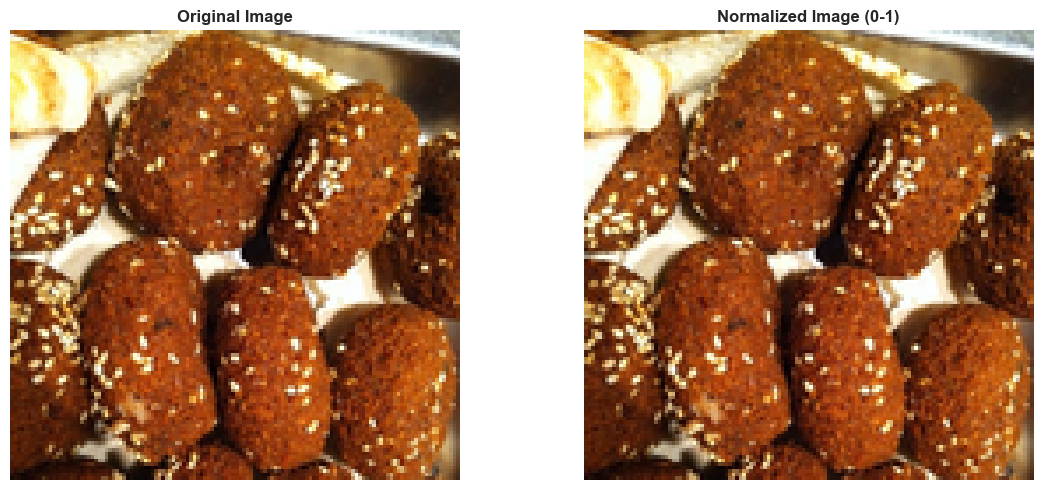

In [9]:
# Display original pixel value statistics
print("Original pixel value statistics:")
print('  Min value:', X.min())
print('  Max value:', X.max())
print('  Mean value:', round(X.mean(), 2))
print('  Std deviation:', round(X.std(), 2))

# Normalize pixel values to 0-1 range
X_normalized = X.astype('float32') / 255.0

# Display normalized pixel value statistics
print("\nNormalized pixel value statistics (0-1 range):")
print('  Min value:', round(X_normalized.min(), 4))
print('  Max value:', round(X_normalized.max(), 4))
print('  Mean value:', round(X_normalized.mean(), 4))
print('  Std deviation:', round(X_normalized.std(), 4))

# Visualize effect of normalization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original image
sample_idx = 850
axes[0].imshow(X[sample_idx].astype('uint8'))
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Normalized image
axes[1].imshow(X_normalized[sample_idx])
axes[1].set_title('Normalized Image (0-1)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Split Data into Training, Validation, and Testing Sets

In [10]:
# Define split ratios
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X_normalized, y, test_size=TEST_SIZE, random_state=42, stratify=y)

# Second split: separate train and validation from remaining data (70% train, 15% val)
val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size_adjusted, random_state=42, stratify=y_temp)

print("Data Split Summary:\n")
print('\nTotal dataset size:', format(len(X_normalized), ','), 'images')
print('\nTraining set size:', format(len(X_train), ','), 'images', '(' + str(round(len(X_train)/len(X_normalized)*100, 1)) + '%)')
print('Validation set size:', format(len(X_val), ','), 'images', '(' + str(round(len(X_val)/len(X_normalized)*100, 1)) + '%)')
print('Testing set size:', format(len(X_test), ','), 'images', '(' + str(round(len(X_test)/len(X_normalized)*100, 1)) + '%)')


Data Split Summary:


Total dataset size: 4,000 images

Training set size: 2,800 images (70.0%)
Validation set size: 600 images (15.0%)
Testing set size: 600 images (15.0%)


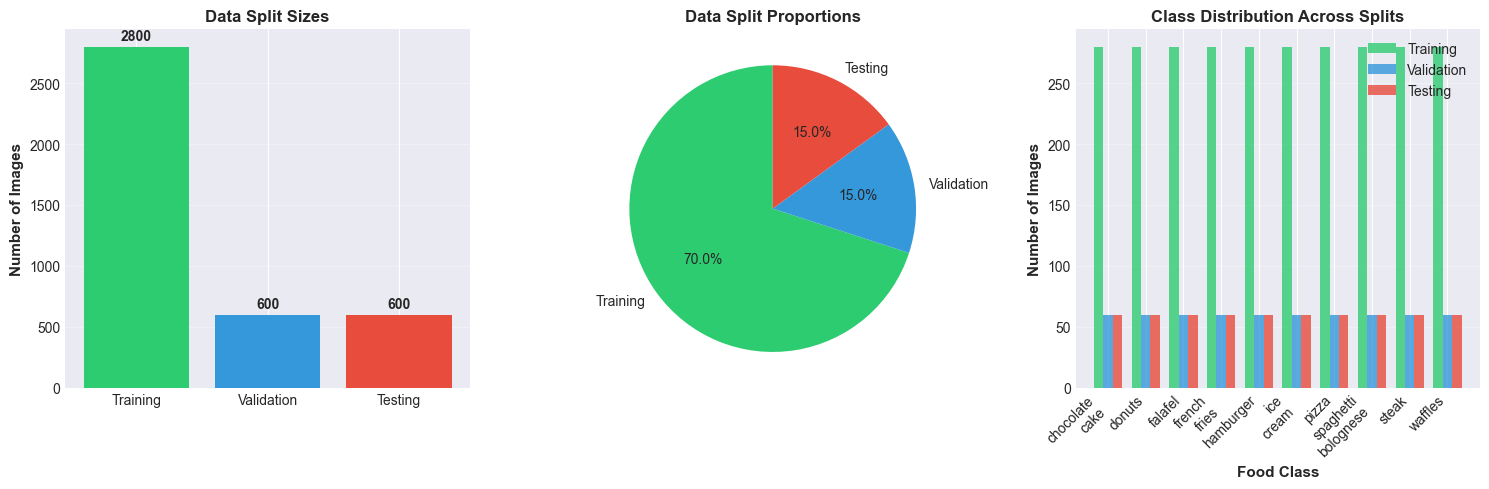

In [11]:
# Visualize the data split
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
split_names = ['Training', 'Validation', 'Testing']
split_sizes = [len(X_train), len(X_val), len(X_test)]
colors = ['#2ecc71', '#3498db', '#e74c3c']

# Bar chart of split sizes
axes[0].bar(split_names, split_sizes, color=colors)
axes[0].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[0].set_title('Data Split Sizes', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(split_sizes):
    axes[0].text(i, v + max(split_sizes)*0.02, str(v), ha='center', fontweight='bold')

# Pie chart of split proportions
axes[1].pie(split_sizes, labels=split_names, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Data Split Proportions', fontsize=12, fontweight='bold')

# Class distribution in train/val/test
y_sets = [y_train, y_val, y_test]
x_pos = np.arange(len(class_names))
width = 0.25

for i, (y_set, set_name, color) in enumerate(zip(y_sets, split_names, colors)):
    _, counts = np.unique(y_set, return_counts=True)
    axes[2].bar(x_pos + i*width, counts, width, label=set_name, color=color, alpha=0.8)

axes[2].set_xlabel('Food Class', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[2].set_title('Class Distribution Across Splits', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_pos + width)
axes[2].set_xticklabels([name.replace('_', '\n') for name in class_names], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Stage 2: Build a Custom CNN from Scratch

2026-05-11 20:04:42.349242: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-05-11 20:04:42.349271: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-05-11 20:04:42.349275: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.72 GB
2026-05-11 20:04:42.349289: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-11 20:04:42.349297: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,970 (16.36 MB)

 Trainable params: 4,288,970 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Total trainable parameters: 4,288,970
Epoch 1/30


2026-05-11 20:04:42.989606: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1446 - loss: 2.3352 - val_accuracy: 0.1700 - val_loss: 2.2244
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2414 - loss: 2.0702 - val_accuracy: 0.2783 - val_loss: 2.0390
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2696 - loss: 2.0503 - val_accuracy: 0.2450 - val_loss: 2.0547
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3075 - loss: 1.9456 - val_accuracy: 0.2983 - val_loss: 2.0507
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2525 - loss: 2.3153 - val_accuracy: 0.2600 - val_loss: 2.1017
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2907 - loss: 2.0568 - val_accuracy: 0.2533 - val_loss: 2.0625
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3221 - loss: 2.0436 - val_accuracy: 0.2583 - val_loss: 2.2515
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3461 - loss: 1.9713 - val_accuracy: 0.2367 - val_loss: 2.

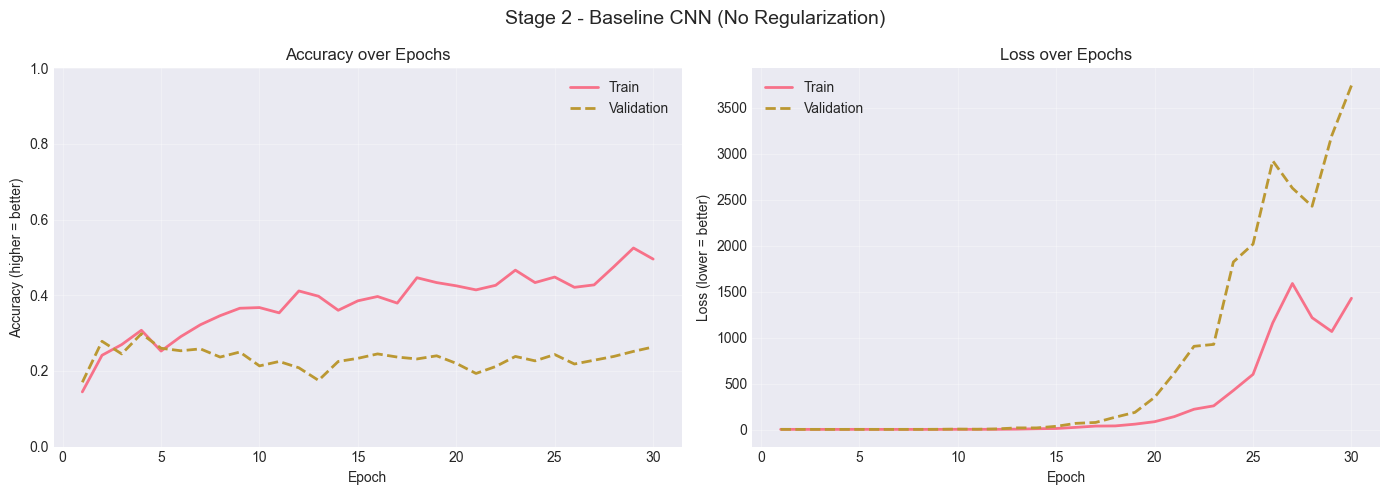

Stage 2 baseline results
train accuracy: 49.6 %
validation accuracy: 26.3 %
best validation accuracy: 29.8 %
test accuracy: 25.3 %
overfitting gap (train - val): 23.2 %


In [12]:
# Stage 2: Custom CNN from scratch — baseline (no regularization)
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

# Build the CNN manually
custom_cnn = models.Sequential([
    layers.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3)),

    # Block 1 — low-level features (edges, textures)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — mid-level features
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — high-level food-specific features
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to a vector
    layers.Flatten(),

    # Classifier head
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

custom_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary and trainable parameters
custom_cnn.summary()
print('Total trainable parameters:', format(custom_cnn.count_params(), ','))

# Train
history = custom_cnn.fit( X_train, y_train,validation_data=(X_val, y_val),epochs=30,batch_size=32,verbose=1)

#Accuracy and loss curves
history_dict = history.history
epochs_range = range(1, len(history_dict['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 2 - Baseline CNN (No Regularization)', fontsize=14)

axes[0].plot(epochs_range, history_dict['accuracy'],     label='Train',      linewidth=2)
axes[0].plot(epochs_range, history_dict['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_dict['loss'],     label='Train',      linewidth=2)
axes[1].plot(epochs_range, history_dict['val_loss'], label='Validation', linewidth=2, linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (lower = better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

val_loss, val_acc   = custom_cnn.evaluate(X_val,  y_val,  verbose=0)
test_loss, test_acc = custom_cnn.evaluate(X_test, y_test, verbose=0)
best_val_acc        = max(history_dict['val_accuracy'])
final_train_acc     = history_dict['accuracy'][-1]
gap = final_train_acc - val_acc

print('Stage 2 baseline results')
print('train accuracy:', round(final_train_acc * 100, 1), '%')
print('validation accuracy:', round(val_acc * 100, 1), '%')
print('best validation accuracy:', round(best_val_acc * 100, 1), '%')
print('test accuracy:', round(test_acc * 100, 1), '%')
print('overfitting gap (train - val):', round(gap * 100, 1), '%')

## Why CNNs are suitable for image classification
CNNs process images by scanning small local patches (kernels) across the entire image, so they naturally capture spatial patterns like edges, shapes, and textures regardless of where they appear. Fully connected networks would need to treat every pixel independently, leading to millions of parameters and poor generalization. CNNs share weights across positions, making them far more efficient and effective for images.

## Purpose of each layer
| Layer | Purpose |
|-------|---------|
| `Conv2D` | Applies learnable filters to extract visual features from the input. |
| `ReLU activation` | Introduces non-linearity so the network can learn complex decision boundaries. |
| `MaxPooling2D` | Downsamples feature maps, reducing size and computation while keeping the strongest activations. |
| `Flatten` | Converts the 2D feature maps into a 1D vector so Dense layers can process them. |
| `Dense` | Combines extracted features to form class-level decision boundaries. |
| `Softmax output` | Produces a probability distribution over the 10 food classes; the class with the highest probability is the prediction. |

## Trainable parameters
The model summary above lists the parameter count per layer. The total is reported after the summary.

# Stage 3: Regularization and Overfitting Prevention

In [ ]:
# Stage 3: Regularized CNN — applying 5 techniques to reduce overfitting
# Techniques used: Dropout, Batch Normalization, Early Stopping, Data Augmentation, L2 regularization
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

# Technique 4: Data Augmentation — show the model more variation per image
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
], name='augmentation')

# Regularized CNN (same 3-block architecture as Stage 2 baseline)
regularized_cnn = models.Sequential([
    layers.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3)),
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),          # Technique 2: Batch Normalization
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    
    # Technique 1: Dropout (60%) + Technique 5: L2 weight regularization
    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.6),

    layers.Dense(len(class_names), activation='softmax')
])

regularized_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

regularized_cnn.summary()
print('Total trainable parameters:', format(regularized_cnn.count_params(), ','))

# Early Stopping: stop when val_accuracy stops improving (patience=8)
early_stop  = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)
# Reduce LR when training stagnates (helps with augmented data)
reduce_lr   = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

history_reg = regularized_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Results
reg_dict = history_reg.history
val_loss_reg, val_acc_reg = regularized_cnn.evaluate(X_val,  y_val,  verbose=0)
test_loss_reg, test_acc_reg = regularized_cnn.evaluate(X_test, y_test, verbose=0)
best_val_reg = max(reg_dict['val_accuracy'])
final_train_reg = reg_dict['accuracy'][-1]
gap_reg = final_train_reg - val_acc_reg

print('Stage 3 regularized results')
print('train accuracy:', round(final_train_reg * 100, 1), '%')
print('validation accuracy:', round(val_acc_reg * 100, 1), '%')
print('best validation accuracy:', round(best_val_reg * 100, 1), '%')
print('test accuracy:', round(test_acc_reg * 100, 1), '%')
print('overfitting gap (train - val):', round(gap_reg * 100, 1), '%')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,290,378 (16.37 MB)

 Trainable params: 4,289,674 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

Total trainable parameters: 4,290,378
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.2021 - loss: 2.5934 - val_accuracy: 0.1083 - val_loss: 2.5895 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.2529 - loss: 2.2800 - val_accuracy: 0.1483 - val_loss: 2.9230 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.2950 - loss: 2.1122 - val_accuracy: 0.1517 - val_loss: 3.0542 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3239 - loss: 1.9838 - val_accuracy: 0.1633 - val_loss: 3.0200 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3671 - loss: 1.8555 - val_accuracy: 0.1500 - val_loss: 2.7421 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.4239 - loss: 1.7764 - val_accuracy: 0.1533 - val_loss: 3.0229 - learning_rate: 0.0010
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc

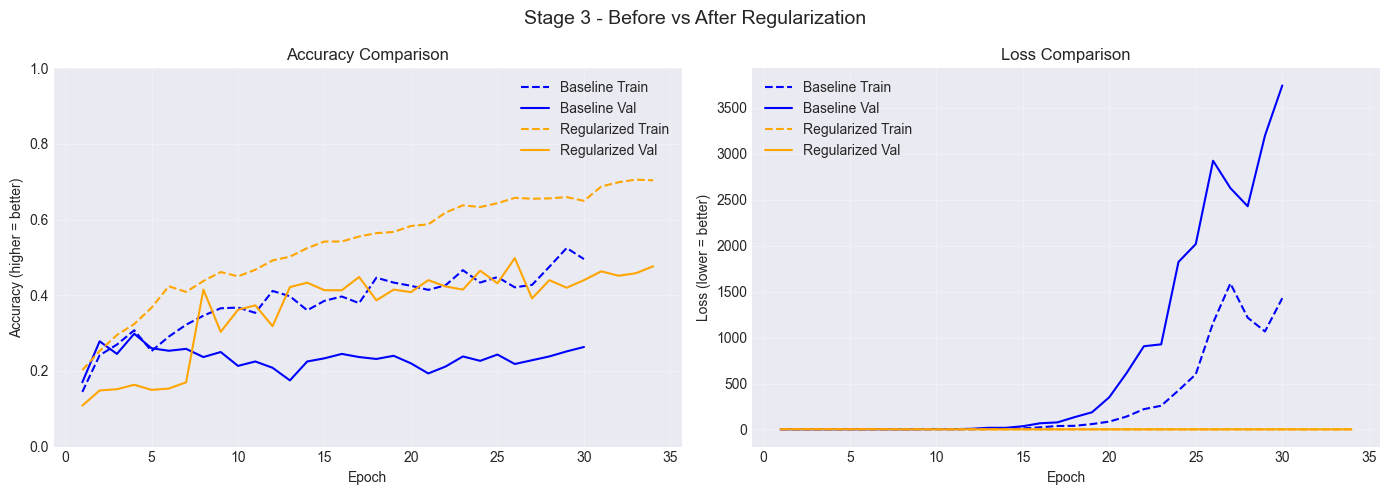

Overfitting comparison
baseline train accuracy: 49.6 %
baseline validation accuracy: 26.3 %
baseline test accuracy: 25.3 %
baseline overfitting gap: 23.2 %
regularized train accuracy: 70.4 %
regularized validation accuracy: 49.8 %
regularized test accuracy: 48.3 %
regularized overfitting gap: 20.6 %
Regularization reduced overfitting.


In [14]:
# Stage 3: Before vs After Regularization comparison

baseline_epochs = range(1, len(history_dict['accuracy']) + 1)
reg_epochs      = range(1, len(reg_dict['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 3 - Before vs After Regularization', fontsize=14)

# Accuracy comparison
axes[0].plot(baseline_epochs, history_dict['accuracy'],     color='blue',   linestyle='--', label='Baseline Train')
axes[0].plot(baseline_epochs, history_dict['val_accuracy'], color='blue',   linestyle='-',  label='Baseline Val')
axes[0].plot(reg_epochs,      reg_dict['accuracy'],         color='orange', linestyle='--', label='Regularized Train')
axes[0].plot(reg_epochs,      reg_dict['val_accuracy'],     color='orange', linestyle='-',  label='Regularized Val')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss comparison
axes[1].plot(baseline_epochs, history_dict['loss'],     color='blue',   linestyle='--', label='Baseline Train')
axes[1].plot(baseline_epochs, history_dict['val_loss'], color='blue',   linestyle='-',  label='Baseline Val')
axes[1].plot(reg_epochs,      reg_dict['loss'],         color='orange', linestyle='--', label='Regularized Train')
axes[1].plot(reg_epochs,      reg_dict['val_loss'],     color='orange', linestyle='-',  label='Regularized Val')
axes[1].set_title('Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (lower = better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

baseline_gap = final_train_acc - val_acc
regularized_gap = final_train_reg - val_acc_reg

print('Overfitting comparison')
print('baseline train accuracy:', round(final_train_acc * 100, 1), '%')
print('baseline validation accuracy:', round(val_acc * 100, 1), '%')
print('baseline test accuracy:', round(test_acc * 100, 1), '%')
print('baseline overfitting gap:', round(baseline_gap * 100, 1), '%')
print('regularized train accuracy:', round(final_train_reg * 100, 1), '%')
print('regularized validation accuracy:', round(val_acc_reg * 100, 1), '%')
print('regularized test accuracy:', round(test_acc_reg * 100, 1), '%')
print('regularized overfitting gap:', round(regularized_gap * 100, 1), '%')

if regularized_gap < baseline_gap:
    print('Regularization reduced overfitting.')
else:
    print('Model may need more tuning.')

## Regularization Techniques Applied

| Technique | What it does | Where applied |
|-----------|-------------|---------------|
| **Dropout (60%)** | Randomly disables 60% of neurons each training step, forcing the network not to rely on any single path. This improves robustness and helps reduce overfitting. | After the Dense(128) layer |
| **Batch Normalization** | Normalizes activations so values stay in a stable range. This smooths optimization, can speed convergence, and often provides mild regularization. | After every Conv2D block and after Dense(128) |
| **Early Stopping** | Monitors **validation accuracy** and stops training when it no longer improves (`patience=8`). Restores the best weights seen so far. | Keras callback during training |
| **Data Augmentation** | Randomly flips, rotates, and zooms training images, increasing sample diversity and reducing memorization of exact pixels. | First layer of the model |
| **L2 Regularization** | Adds a penalty for large weights ($\lambda=10^{-4}$), encouraging smaller weights and better generalization. | Dense(128) kernel |

## Why overfitting happened in Stage 2
In Stage 2, training accuracy increased while validation performance stayed clearly lower and less stable. That pattern indicates overfitting: the model learned training-specific details that did not generalize as well to unseen data.

## What regularization improved
By combining the five techniques above, the model is encouraged to:
- Learn more general visual features (augmentation)
- Avoid relying on a narrow set of neurons (dropout)
- Keep weights smoother and less extreme (L2)
- Train with more stable activations (batch norm)
- Stop before late-epoch overfitting worsens (early stopping)

# Stage 5: Transfer Learning Models

In [15]:
# Stage 5 - Transfer Learning: Setup, preprocessing, and training loop
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

NUM_CLASSES = len(class_names)
IMG_SIZE = TARGET_SIZE

# Preprocess data for each model
_raw = {split: arr * 255.0 for split, arr in [('train', X_train), ('val', X_val), ('test', X_test)]}

tl_data = {
    'resnet50': {s: resnet_preprocess(v.copy()) for s, v in _raw.items()},
    'mobilenetv2': {s: mobilenet_preprocess(v.copy()) for s, v in _raw.items()},
    'efficientnetb0': {s: effnet_preprocess(v.copy()) for s, v in _raw.items()},
}

print('Preprocessing complete')
for k in tl_data:
    print(f'{k}: {tl_data[k]["train"].shape}')

# Helper functions
def get_metrics(model, X, y):
    """Return (accuracy, precision, recall, f1) on dataset (X, y)."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = accuracy_score(y, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y, y_pred, average='weighted', zero_division=0)
    return float(acc), float(p), float(r), float(f1)

def make_callbacks(patience=6):
    return [
        EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-7, verbose=0),
    ]

def build_classification_head(base_model, num_classes):
    """Add custom classification head to base model."""
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inp, out)

# Results storage
tl_results = {}

print('Stage 5 setup complete')


Preprocessing complete
resnet50: (2800, 128, 128, 3)
mobilenetv2: (2800, 128, 128, 3)
efficientnetb0: (2800, 128, 128, 3)
Stage 5 setup complete


## Transfer Learning: Three Pretrained Models

This stage trains **3 different pretrained architectures**, each with **2 experiments** (Feature Extractor + Fine-Tuning) in the unified training loop below.

### Model 1: ResNet50
- **Type:** 50-layer deep residual network (~23M parameters)
- **Key Feature:** Skip connections enable very deep training without vanishing gradients
- **Exp A:** Freeze all base layers; train only new classification head
- **Exp B:** Warm up head (5 epochs), unfreeze last 53 layers, fine-tune with LR = 1e-5

### Model 2: MobileNetV2
- **Type:** Lightweight efficient model (~3.4M parameters)
- **Key Feature:** Inverted residual blocks + depthwise separable convolutions for speed
- **Exp A:** Freeze all base layers; train only new classification head
- **Exp B:** Warm up head (5 epochs), unfreeze last 30 layers, fine-tune with LR = 1e-5

### Model 3: EfficientNetB0
- **Type:** Compound-scaled efficient baseline (~5.3M parameters)
- **Key Feature:** Balanced scaling of depth, width, and resolution for efficiency
- **Exp A:** Freeze all base layers; train only new classification head
- **Exp B:** Warm up head (5 epochs), unfreeze last 40 layers, fine-tune with LR = 1e-5

In [16]:
# Stage 5 - Train all models: Feature Extractor + Fine-Tuning for each architecture

model_configs = [
    {
        'name': 'ResNet50',
        'app_class': ResNet50,
        'data_key': 'resnet50',
        'unfreeze_depth': 53,  # Last convolutional block
    },
    {
        'name': 'MobileNetV2',
        'app_class': MobileNetV2,
        'data_key': 'mobilenetv2',
        'unfreeze_depth': 30,  # Last inverted residual block
    },
    {
        'name': 'EfficientNetB0',
        'app_class': EfficientNetB0,
        'data_key': 'efficientnetb0',
        'unfreeze_depth': 40,  # Last two blocks
    },
]

for config in model_configs:
    model_name = config['name']
    app_class = config['app_class']
    data_key = config['data_key']
    unfreeze_depth = config['unfreeze_depth']

    X_train_tl = tl_data[data_key]['train']
    X_val_tl = tl_data[data_key]['val']
    X_test_tl = tl_data[data_key]['test']

    print(f'\n{"="*60}')
    print(f'{model_name}: Experiment A - Feature Extractor')
    print(f'{"="*60}')

    base_a = app_class(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_a.trainable = False
    model_a = build_classification_head(base_a, NUM_CLASSES)
    model_a.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    print(f'Total params: {model_a.count_params():,} | Trainable: {sum(np.prod(v.shape) for v in model_a.trainable_variables):,}')

    t0 = time.time()
    hist_a = model_a.fit(
        X_train_tl, y_train,
        validation_data=(X_val_tl, y_val),
        epochs=30,
        batch_size=32,
        callbacks=make_callbacks(patience=6),
        verbose=1,
    )
    time_a = time.time() - t0

    y_pred_a = np.argmax(model_a.predict(X_test_tl, verbose=0), axis=1)
    acc_a, p_a, r_a, f1_a = get_metrics(model_a, X_test_tl, y_test)
    best_val_a = max(hist_a.history['val_accuracy'])

    tl_results[f'{model_name} — Exp A'] = {
        'model_label': model_name,
        'experiment': 'Feature Extractor',
        'acc': acc_a,
        'precision': p_a,
        'recall': r_a,
        'f1': f1_a,
        'best_val_acc': best_val_a,
        'train_time': time_a,
        'total_params': model_a.count_params(),
        'trainable_params': sum(np.prod(v.shape) for v in model_a.trainable_variables),
        'history': hist_a.history,
        'model': model_a,
        'X_test': X_test_tl,
        'y_pred': y_pred_a,
    }

    print(f'Results: Test Accuracy={acc_a*100:.1f}% | F1={f1_a*100:.1f}% | Time={time_a:.0f}s')

    print(f'\n{model_name}: Experiment B - Fine-Tuning')
    print('="*40')

    base_b = app_class(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_b.trainable = False
    model_b = build_classification_head(base_b, NUM_CLASSES)
    model_b.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    print('Phase 1: Warm-up head (5 epochs)')
    model_b.fit(X_train_tl, y_train, validation_data=(X_val_tl, y_val), epochs=5, batch_size=32, verbose=1)

    print(f'Phase 2: Unfreeze last {unfreeze_depth} layers')
    base_b.trainable = True
    freeze_until = len(base_b.layers) - unfreeze_depth
    for layer in base_b.layers[:freeze_until]:
        layer.trainable = False

    model_b.compile(optimizer=Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist_b = model_b.fit(
        X_train_tl, y_train,
        validation_data=(X_val_tl, y_val),
        epochs=25,
        batch_size=32,
        callbacks=make_callbacks(patience=6),
        verbose=1,
    )
    time_b = time.time() - t0

    y_pred_b = np.argmax(model_b.predict(X_test_tl, verbose=0), axis=1)
    acc_b, p_b, r_b, f1_b = get_metrics(model_b, X_test_tl, y_test)
    best_val_b = max(hist_b.history['val_accuracy'])

    tl_results[f'{model_name} — Exp B'] = {
        'model_label': model_name,
        'experiment': 'Fine-Tuning',
        'acc': acc_b,
        'precision': p_b,
        'recall': r_b,
        'f1': f1_b,
        'best_val_acc': best_val_b,
        'train_time': time_b,
        'total_params': model_b.count_params(),
        'trainable_params': sum(np.prod(v.shape) for v in model_b.trainable_variables),
        'history': hist_b.history,
        'model': model_b,
        'X_test': X_test_tl,
        'y_pred': y_pred_b,
    }

    print(f'Results: Test Accuracy={acc_b*100:.1f}% | F1={f1_b*100:.1f}% | Time={time_b:.0f}s')

print('\nAll 6 experiments complete!')


ResNet50: Experiment A - Feature Extractor
Total params: 24,114,826 | Trainable: 527,114
Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.5229 - loss: 3.5157 - val_accuracy: 0.7150 - val_loss: 1.4767 - learning_rate: 0.0010
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6832 - loss: 2.3562 - val_accuracy: 0.7333 - val_loss: 1.6383 - learning_rate: 0.0010
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7057 - loss: 2.0663 - val_accuracy: 0.7650 - val_loss: 1.5381 - learning_rate: 0.0010
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7507 - loss: 1.7486 - val_accuracy: 0.7650 - val_loss: 1.6456 - learning_rate: 0.0010
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7682 - loss: 1.6555 - val_accuracy: 0.7750 - val_loss: 1.6774 - learning_rate: 0.0010
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7907 - loss: 1.4375 - val_accuracy: 0.7467 - val_loss: 1.8518 - learning_rate: 0.0010
Epoc

Comparing all 6 experiments

         Model        Experiment  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)  Best Val (%)  Train Time (s)  Params (M)
      ResNet50 Feature Extractor          77.8           78.6        77.8          77.8          77.5            31.0        24.1
      ResNet50       Fine-Tuning          77.0           77.5        77.0          77.1          75.8           139.0        24.1
   MobileNetV2 Feature Extractor          79.0           79.5        79.0          79.1          79.2            20.0         2.6
   MobileNetV2       Fine-Tuning          80.5           81.0        80.5          80.5          77.7            54.0         2.6
EfficientNetB0 Feature Extractor          80.2           80.3        80.2          80.1          80.8            30.0         4.4
EfficientNetB0       Fine-Tuning          76.5           77.3        76.5          76.4          75.3            87.0         4.4


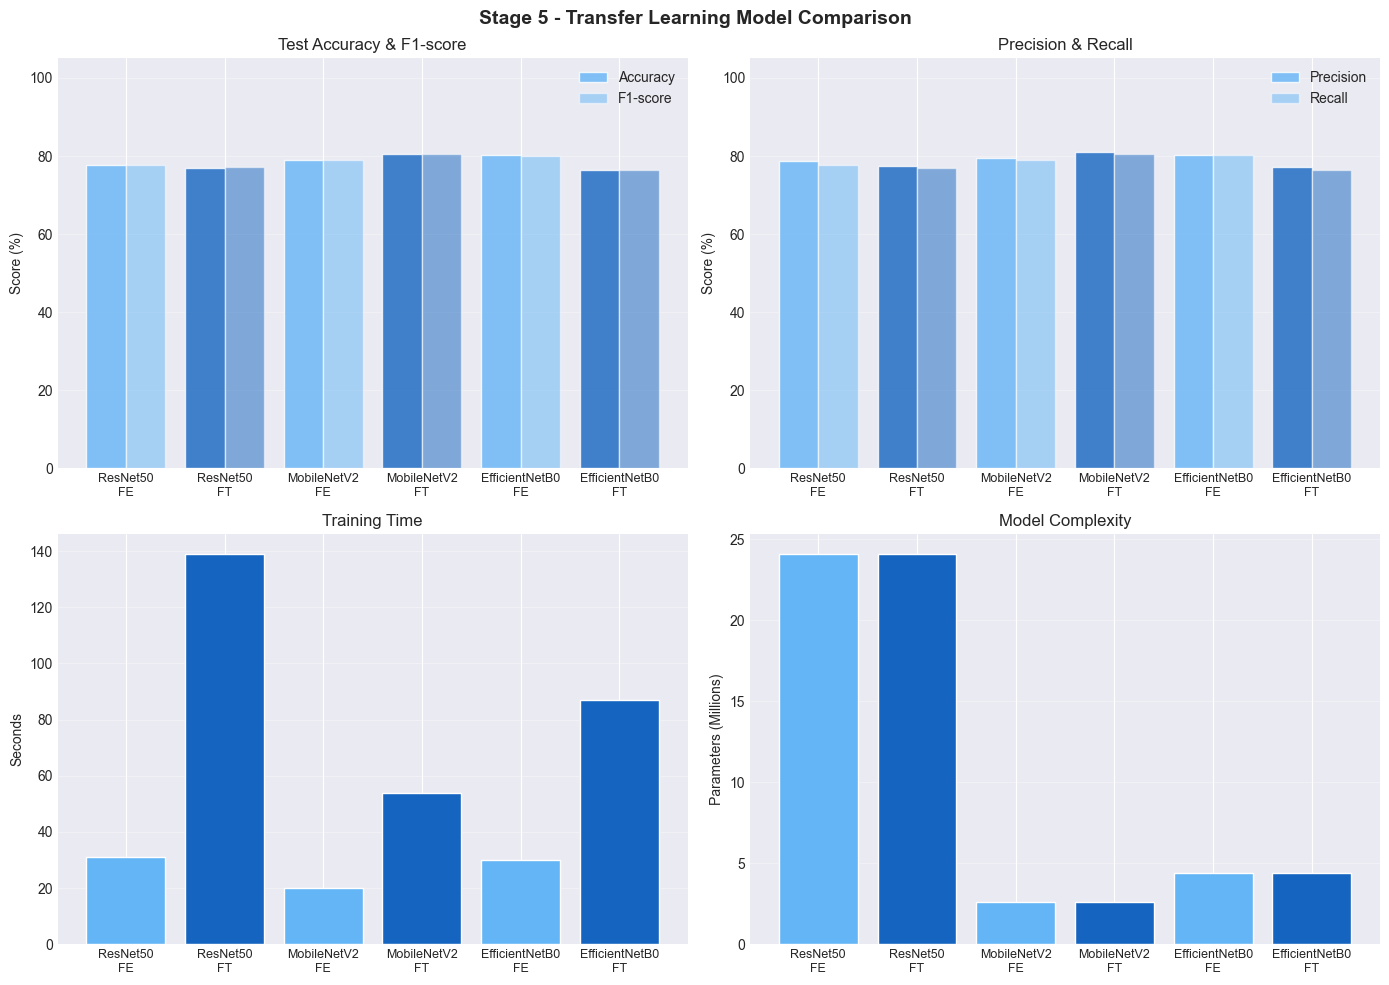


SUMMARY
Best F1-score: MobileNetV2 (Fine-Tuning) - 80.5%
Fastest: MobileNetV2 (Feature Extractor) - 20s
Smallest: MobileNetV2 (Feature Extractor) - 2.6M parameters


In [17]:
# Stage 5 - Comparison: All models side by side
print('Comparing all 6 experiments\n')

# Build results table
rows = []
for key, r in tl_results.items():
    rows.append({
        'Model': r['model_label'],
        'Experiment': r['experiment'],
        'Accuracy (%)': round(r['acc'] * 100, 1),
        'Precision (%)': round(r['precision'] * 100, 1),
        'Recall (%)': round(r['recall'] * 100, 1),
        'F1-score (%)': round(r['f1'] * 100, 1),
        'Best Val (%)': round(r['best_val_acc'] * 100, 1),
        'Train Time (s)': round(r['train_time'], 0),
        'Params (M)': round(r['total_params'] / 1e6, 1),
    })

df_comp = pd.DataFrame(rows)
print(df_comp.to_string(index=False))

# Visualization: 2x2 grid comparing metrics
x = np.arange(len(df_comp))
labels = [f"{r['Model']}\n{'FE' if r['Experiment']=='Feature Extractor' else 'FT'}" 
          for _, r in df_comp.iterrows()]
colors = ['#64B5F6' if r['Experiment']=='Feature Extractor' else '#1565C0' for _, r in df_comp.iterrows()]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Stage 5 - Transfer Learning Model Comparison', fontsize=14, fontweight='bold')

# (0,0) Accuracy & F1
ax = axes[0, 0]
ax.bar(x - 0.2, df_comp['Accuracy (%)'], 0.4, label='Accuracy', color=colors, alpha=0.8, edgecolor='white')
ax.bar(x + 0.2, df_comp['F1-score (%)'], 0.4, label='F1-score', color=colors, alpha=0.5, edgecolor='white')
ax.set_ylabel('Score (%)')
ax.set_title('Test Accuracy & F1-score')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# (0,1) Precision & Recall
ax = axes[0, 1]
ax.bar(x - 0.2, df_comp['Precision (%)'], 0.4, label='Precision', color=colors, alpha=0.8, edgecolor='white')
ax.bar(x + 0.2, df_comp['Recall (%)'], 0.4, label='Recall', color=colors, alpha=0.5, edgecolor='white')
ax.set_ylabel('Score (%)')
ax.set_title('Precision & Recall')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# (1,0) Training time
ax = axes[1, 0]
ax.bar(x, df_comp['Train Time (s)'], color=colors, edgecolor='white')
ax.set_ylabel('Seconds')
ax.set_title('Training Time')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.grid(axis='y', alpha=0.3)

# (1,1) Model size
ax = axes[1, 1]
ax.bar(x, df_comp['Params (M)'], color=colors, edgecolor='white')
ax.set_ylabel('Parameters (Millions)')
ax.set_title('Model Complexity')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print('\n' + '='*60)
print('SUMMARY')
print('='*60)
best_f1_idx = df_comp['F1-score (%)'].idxmax()
best_speed_idx = df_comp['Train Time (s)'].idxmin()
best_small_idx = df_comp['Params (M)'].idxmin()

print(f"Best F1-score: {df_comp.loc[best_f1_idx, 'Model']} ({df_comp.loc[best_f1_idx, 'Experiment']}) - {df_comp.loc[best_f1_idx, 'F1-score (%)']:.1f}%")
print(f"Fastest: {df_comp.loc[best_speed_idx, 'Model']} ({df_comp.loc[best_speed_idx, 'Experiment']}) - {df_comp.loc[best_speed_idx, 'Train Time (s)']:.0f}s")
print(f"Smallest: {df_comp.loc[best_small_idx, 'Model']} ({df_comp.loc[best_small_idx, 'Experiment']}) - {df_comp.loc[best_small_idx, 'Params (M)']:.1f}M parameters")


## Stage 5 Results Interpretation

The transfer-learning comparison shows a clear pattern:
- **Best overall test performance:** **MobileNetV2 (Fine-Tuning)** (highest accuracy/F1 in this run)
- **Second-best overall:** **EfficientNetB0 (Feature Extractor)**
- **Weakest result:** **EfficientNetB0 (Fine-Tuning)** in this run

Fine-tuning did **not** help all backbones equally:
- It **improved MobileNetV2** compared with its feature-extractor setup.
- It **reduced performance for ResNet50 and EfficientNetB0** compared with their feature-extractor setups.

Speed and size trade-offs are also clear:
- **Fastest training:** MobileNetV2 (Feature Extractor)
- **Slowest training:** ResNet50 (Fine-Tuning)
- **Largest models:** ResNet50 variants
- **Smallest models:** MobileNetV2 variants

Overall interpretation for this experiment:
- If priority is **best predictive performance**, choose **MobileNetV2 (Fine-Tuning)**.
- If priority is **strong performance with lower training cost**, **EfficientNetB0 (Feature Extractor)** is a strong choice.
- Full fine-tuning should be used selectively, because in this run it added cost without consistent gains across architectures.

# Stage 6: Comparative Scientific Analysis

This stage compares all available trained models using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Training time
- Model size

It also analyzes:
- Best-performing model
- Weakest classes
- Misclassification cases
- Overfitting behavior
- Speed vs accuracy tradeoff

In [18]:
# Stage 6 - Scientific comparison of all models
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import pandas as pd

rows = []
missing_transfer_cache = False

# Baseline CNNs
if 'custom_cnn' in globals() and 'X_test' in globals() and 'y_test' in globals():
    y_pred = np.argmax(custom_cnn.predict(X_test, verbose=0), axis=1)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    rows.append({
        'Model': 'Custom CNN (Baseline)',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': p,
        'Recall': r,
        'F1-score': f1,
        'Training time (s)': np.nan,
        'Model size (M)': custom_cnn.count_params() / 1e6,
        'Overfitting gap': (final_train_acc - val_acc) if 'final_train_acc' in globals() and 'val_acc' in globals() else np.nan,
        'y_pred': y_pred,
        'X_eval': X_test,
    })

if 'regularized_cnn' in globals() and 'X_test' in globals() and 'y_test' in globals():
    y_pred = np.argmax(regularized_cnn.predict(X_test, verbose=0), axis=1)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    rows.append({
        'Model': 'Custom CNN (Regularized)',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': p,
        'Recall': r,
        'F1-score': f1,
        'Training time (s)': np.nan,
        'Model size (M)': regularized_cnn.count_params() / 1e6,
        'Overfitting gap': (final_train_reg - val_acc_reg) if 'final_train_reg' in globals() and 'val_acc_reg' in globals() else np.nan,
        'y_pred': y_pred,
        'X_eval': X_test,
    })

# Transfer learning models
for key, result in tl_results.items():
    if result.get('y_pred') is None or result.get('X_test') is None:
        missing_transfer_cache = True
    rows.append({
        'Model': f"{result['model_label']} ({result['experiment']})",
        'Accuracy': result['acc'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1-score': result['f1'],
        'Training time (s)': result['train_time'],
        'Model size (M)': result['total_params'] / 1e6,
        'Overfitting gap': max(result['history'].get('accuracy', [np.nan])) - max(result['history'].get('val_accuracy', [np.nan])),
        'y_pred': result.get('y_pred'),
        'X_eval': result.get('X_test'),
    })

if not rows:
    print('No trained models found. Run Stage 2/3/5 cells first.')
else:
    results_df = pd.DataFrame(rows).sort_values('F1-score', ascending=False).reset_index(drop=True)
    print('Stage 6 - Scientific Comparison')
    display(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'Training time (s)', 'Model size (M)', 'Overfitting gap']].round(4))

    best_row = results_df.iloc[0]
    fastest_row = results_df.dropna(subset=['Training time (s)']).sort_values('Training time (s)').iloc[0]
    smallest_row = results_df.sort_values('Model size (M)').iloc[0]

    print('\nBest-performing model:', best_row['Model'])
    print('Fastest model:', fastest_row['Model'])
    print('Smallest model:', smallest_row['Model'])
    print('Total models compared:', len(results_df))
    if missing_transfer_cache:
        print('Note: rerun Stage 5 once to cache transfer-learning predictions for all confusion matrices.')

Stage 6 - Scientific Comparison


,Model,Accuracy,Precision,Recall,F1-score,Training time (s),Model size (M),Overfitting gap
0,MobileNetV2 (Fine-Tuning),0.8050,0.8105,0.8050,0.8046,53.8125,2.5885,0.1083
1,EfficientNetB0 (Feature Extractor),0.8017,0.8026,0.8017,0.8007,29.5414,4.3801,0.1545
2,MobileNetV2 (Feature Extractor),0.7900,0.7954,0.7900,0.7908,20.2302,2.5885,0.1244
3,ResNet50 (Feature Extractor),0.7783,0.7855,0.7783,0.7778,31.3881,24.1148,0.1082
4,ResNet50 (Fine-Tuning),0.7700,0.7750,0.7700,0.7706,139.1253,24.1148,0.2199
5,EfficientNetB0 (Fine-Tuning),0.7650,0.7727,0.7650,0.7642,87.0310,4.3801,0.1217
6,Custom CNN (Regularized),0.4833,0.5036,0.4833,0.4786,NaN,4.2904,0.2056
7,Custom CNN (Baseline),0.2533,0.2860,0.2533,0.2493,NaN,4.2890,0.2324



Best-performing model: MobileNetV2 (Fine-Tuning)
Fastest model: MobileNetV2 (Feature Extractor)
Smallest model: MobileNetV2 (Fine-Tuning)
Total models compared: 8


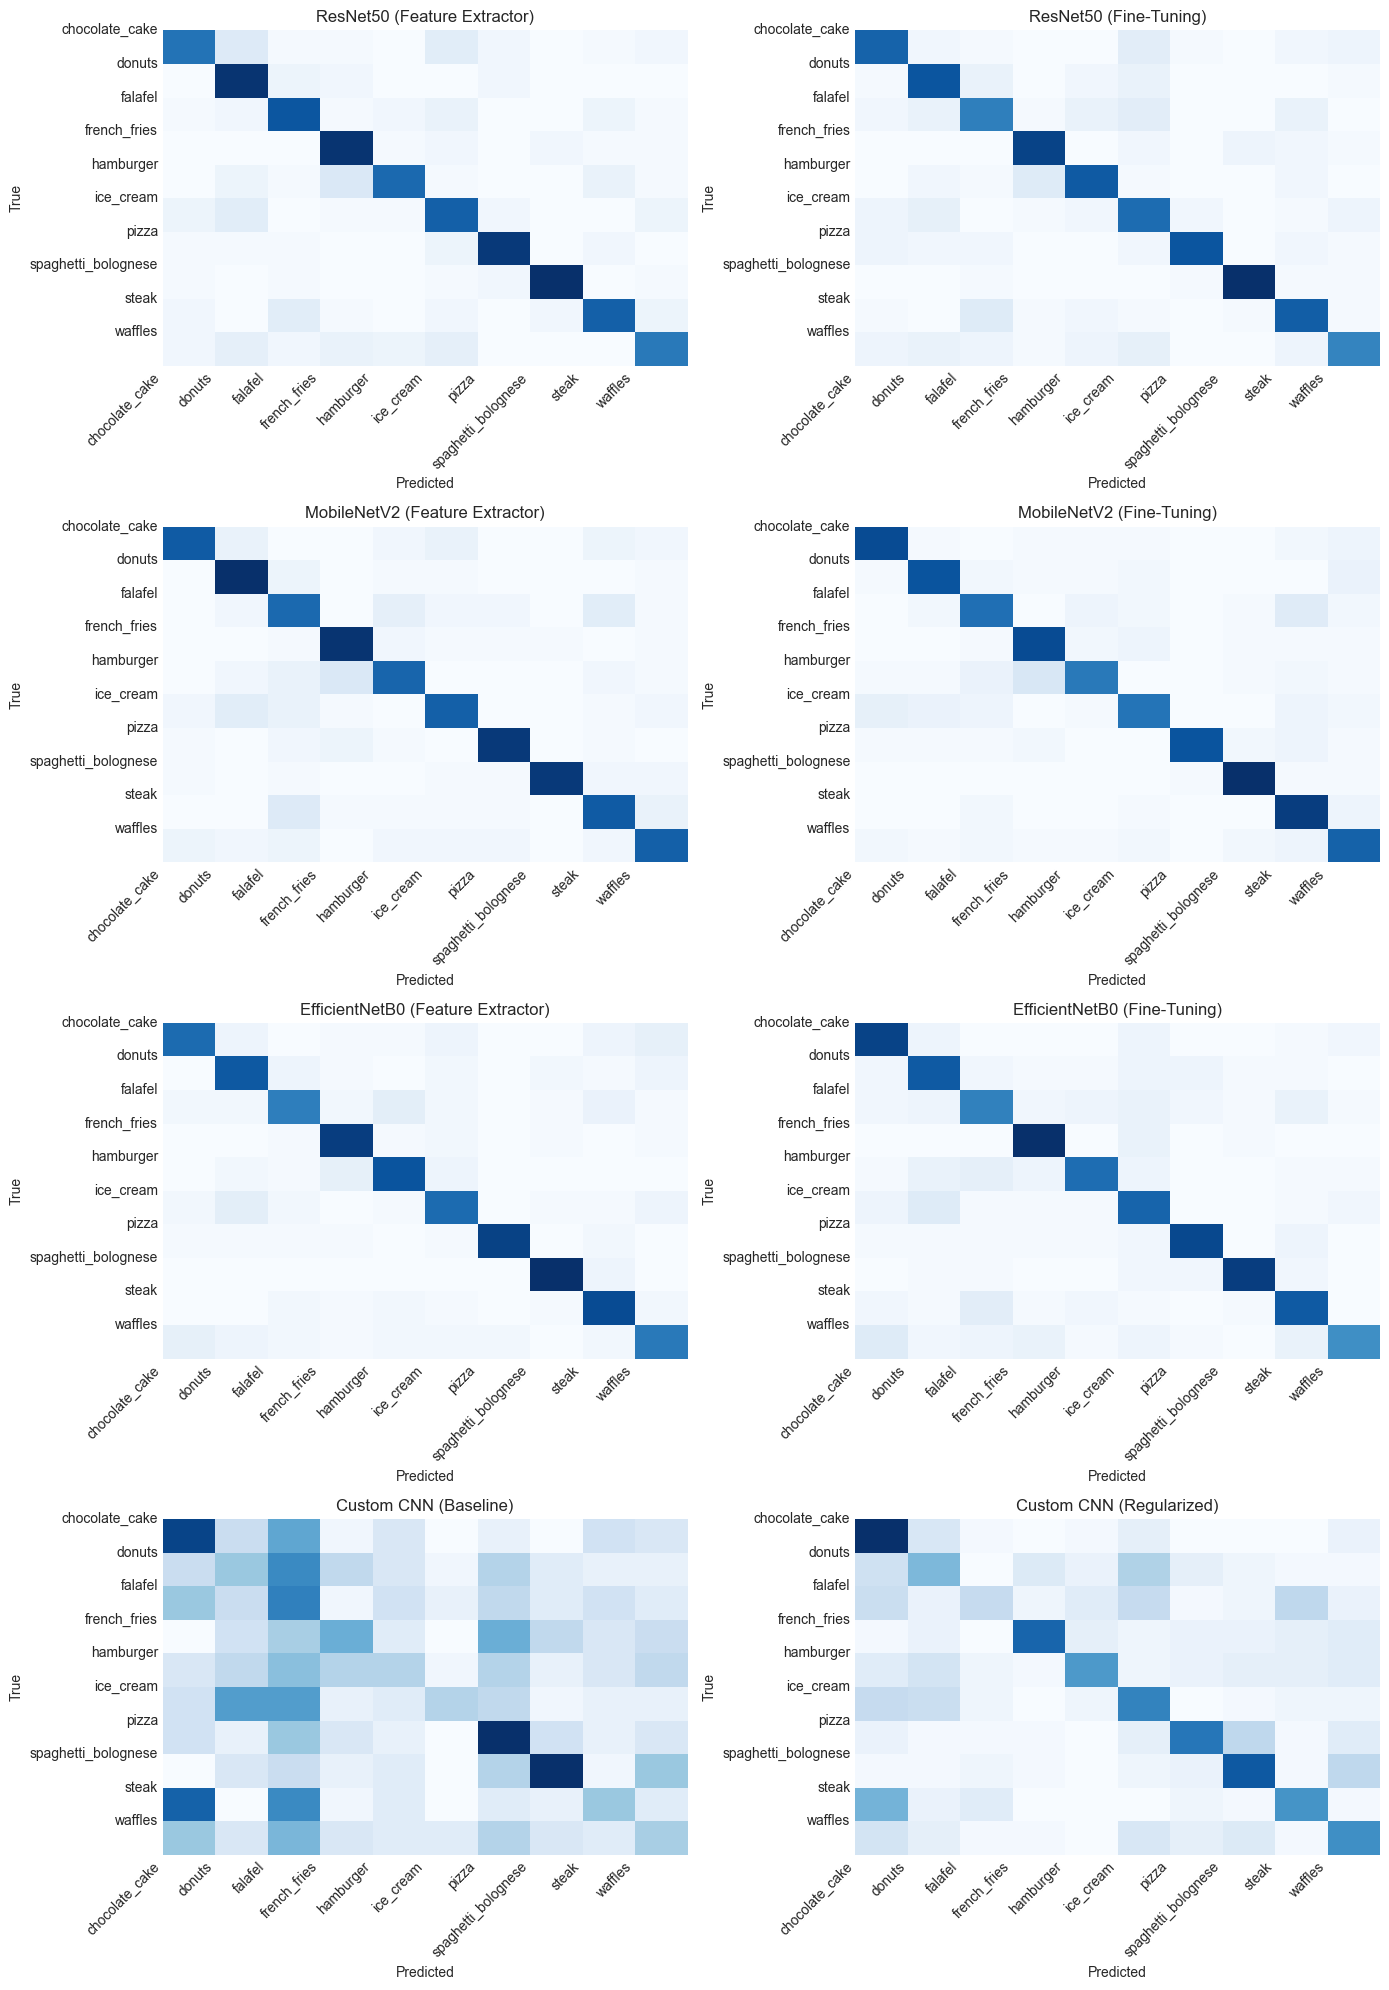

Best-performing model: MobileNetV2 (Fine-Tuning)
Weakest classes for the best model:
- hamburger | recall = 0.683 | most confused with french_fries
- ice_cream | recall = 0.7 | most confused with chocolate_cake
- falafel | recall = 0.717 | most confused with steak
Misclassification cases for best model: 117


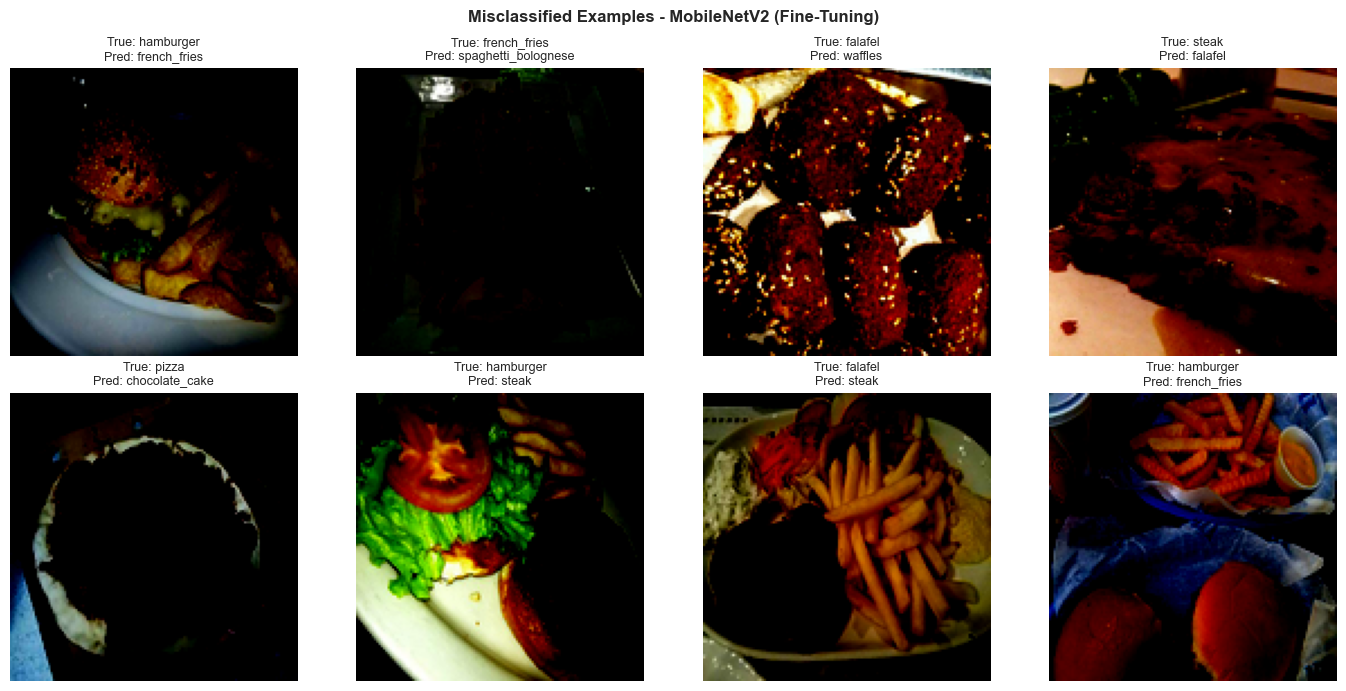

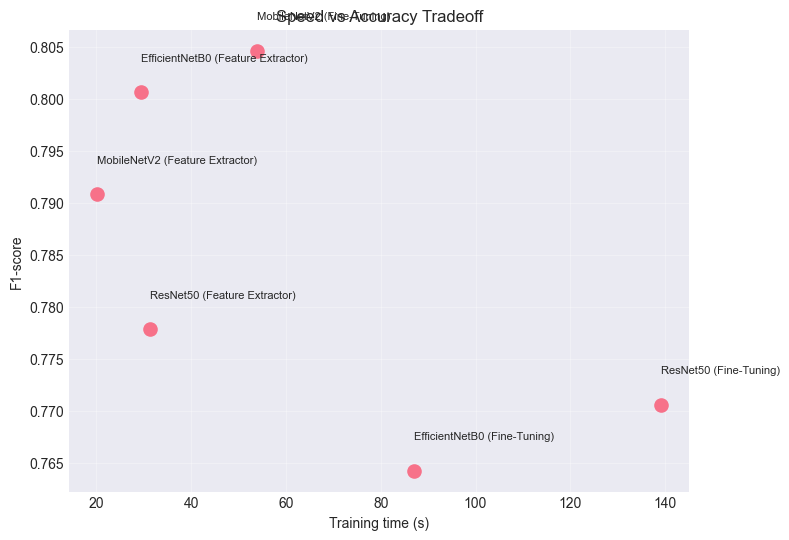

In [19]:
# Stage 6 - Confusion matrices, weakest classes, misclassifications, and speed/accuracy tradeoff
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use the predictions saved in Stage 5 whenever possible.
prediction_rows = []
for _, result in tl_results.items():
    if result.get('y_pred') is not None and result.get('X_test') is not None:
        prediction_rows.append({
            'Model': f"{result['model_label']} ({result['experiment']})",
            'y_pred': result['y_pred'],
            'X_eval': result['X_test'],
        })

# Add baseline CNNs.
if 'custom_cnn' in globals() and 'X_test' in globals() and 'y_test' in globals():
    prediction_rows.append({
        'Model': 'Custom CNN (Baseline)',
        'y_pred': np.argmax(custom_cnn.predict(X_test, verbose=0), axis=1),
        'X_eval': X_test,
    })

if 'regularized_cnn' in globals() and 'X_test' in globals() and 'y_test' in globals():
    prediction_rows.append({
        'Model': 'Custom CNN (Regularized)',
        'y_pred': np.argmax(regularized_cnn.predict(X_test, verbose=0), axis=1),
        'X_eval': X_test,
    })

if not prediction_rows:
    print('No model predictions available. Run Stage 5 first, then rerun Stage 6.')
else:
    # Confusion matrices for every model.
    n_models = len(prediction_rows)
    cols = 2
    rows_n = int(np.ceil(n_models / cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(14, 5 * rows_n))
    axes = np.array(axes).reshape(-1)

    for i, item in enumerate(prediction_rows):
        cm = confusion_matrix(y_test, item['y_pred'])
        sns.heatmap(cm, annot=False, cmap='Blues', cbar=False, ax=axes[i])
        axes[i].set_title(item['Model'])
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')
        axes[i].set_xticks(range(len(class_names)))
        axes[i].set_xticklabels(class_names, rotation=45, ha='right')
        axes[i].set_yticks(range(len(class_names)))
        axes[i].set_yticklabels(class_names, rotation=0)

    for j in range(n_models, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # Weakest classes and misclassification cases for the best model.
    if 'results_df' in globals() and len(results_df) > 0:
        best_name = results_df.iloc[0]['Model']
        best_item = next((item for item in prediction_rows if item['Model'] == best_name), None)
        if best_item is not None:
            best_pred = best_item['y_pred']
            best_eval = best_item['X_eval'] if best_item['X_eval'] is not None else X_test
            cm_best = confusion_matrix(y_test, best_pred)
            per_class_recall = np.diag(cm_best) / np.maximum(cm_best.sum(axis=1), 1)
            weakest_idx = np.argsort(per_class_recall)[:3]

            print('Best-performing model:', best_name)
            print('Weakest classes for the best model:')
            for idx in weakest_idx:
                row = cm_best[idx].copy()
                row[idx] = -1
                confused_as = int(np.argmax(row))
                print('-', class_names[idx], '| recall =', round(float(per_class_recall[idx]), 3), '| most confused with', class_names[confused_as])

            mis_idx = np.where(best_pred != y_test)[0]
            print('Misclassification cases for best model:', len(mis_idx))

            if len(mis_idx) > 0:
                n_show = min(8, len(mis_idx))
                fig, axes = plt.subplots(2, 4, figsize=(14, 7))
                axes = axes.flatten()
                for i in range(8):
                    axes[i].axis('off')
                for i, m in enumerate(mis_idx[:n_show]):
                    image = best_eval[m]
                    if image.max() > 1:
                        image = image / 255.0
                    axes[i].imshow(np.clip(image, 0, 1))
                    axes[i].set_title('True: ' + class_names[y_test[m]] + '\nPred: ' + class_names[best_pred[m]], fontsize=9)
                    axes[i].axis('off')
                plt.suptitle('Misclassified Examples - ' + best_name, fontsize=12, fontweight='bold')
                plt.tight_layout()
                plt.show()

    # Speed vs accuracy tradeoff.
    if 'results_df' in globals() and len(results_df) > 0:
        speed_df = results_df.dropna(subset=['Training time (s)']).copy()
        if len(speed_df) > 0:
            plt.figure(figsize=(8, 6))
            plt.scatter(speed_df['Training time (s)'], speed_df['F1-score'], s=90)
            for _, row in speed_df.iterrows():
                plt.text(row['Training time (s)'], row['F1-score'] + 0.003, row['Model'], fontsize=8)
            plt.xlabel('Training time (s)')
            plt.ylabel('F1-score')
            plt.title('Speed vs Accuracy Tradeoff')
            plt.grid(alpha=0.3)
            plt.show()

## Augmented Image Samples

This visualization shows one original training image and multiple augmented versions generated by the Stage 3 augmentation pipeline.

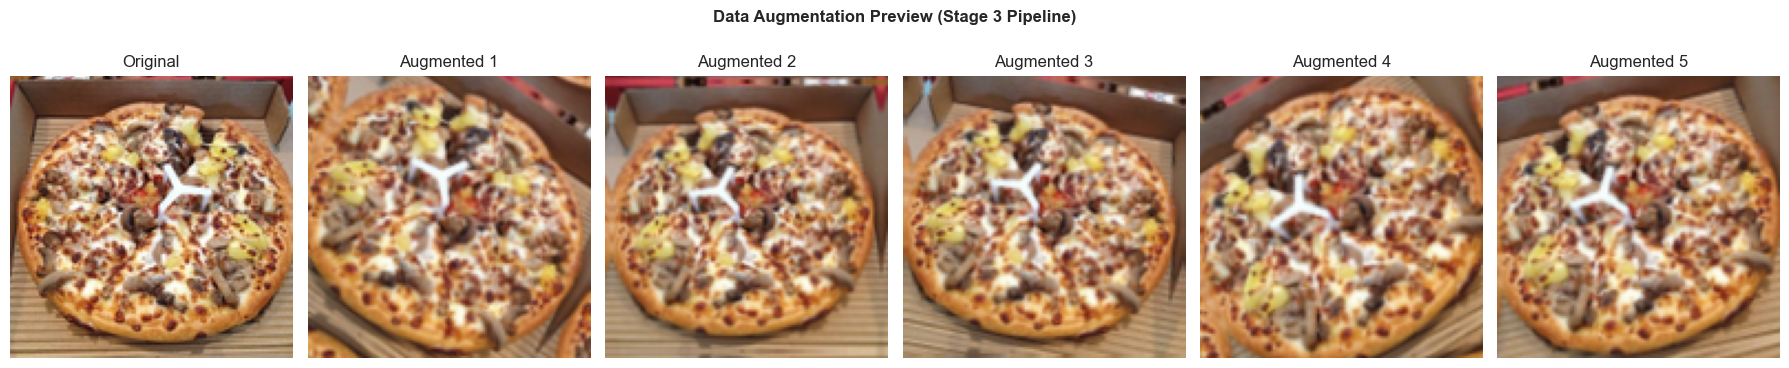

In [20]:
# This cell visualizes data augmentation outputs required in the report.
# It shows one original image and several augmented variants.

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

if 'data_augmentation' not in globals():
    print("data_augmentation is not defined. Run the Stage 3 setup cell first.")
elif 'X_train' not in globals() or len(X_train) == 0:
    print("X_train is not available. Run the data loading/splitting cells first.")
else:
    # Pick one sample image from training data
    sample_idx = 0
    original_img = X_train[sample_idx]

    # Generate augmented versions of the same image
    n_augmented = 5
    augmented_imgs = []
    for _ in range(n_augmented):
        aug = data_augmentation(tf.expand_dims(original_img, axis=0), training=True)
        augmented_imgs.append(tf.squeeze(aug, axis=0).numpy())

    # Plot: original + augmented images
    fig, axes = plt.subplots(1, n_augmented + 1, figsize=(18, 4))
    axes[0].imshow(np.clip(original_img, 0, 1))
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i in range(n_augmented):
        axes[i + 1].imshow(np.clip(augmented_imgs[i], 0, 1))
        axes[i + 1].set_title(f"Augmented {i+1}")
        axes[i + 1].axis("off")

    plt.suptitle("Data Augmentation Preview (Stage 3 Pipeline)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()